In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os


In [17]:
SIM_COL = "fsq_osm_name_similarity_score_trg"
DIST_COL = "fsq_osm_distance"
CSV_PATH = "../../data/revision2/name_similarity_distance_only.csv"
os.makedirs("figs", exist_ok=True)

In [ ]:
def get_data(
    name_similarity_threshold=0.0,
    distance_threshold=0.0015,
    bins=100,
    chunk_size=1_000_000,
):
    sim_bins = np.linspace(name_similarity_threshold, 1, bins + 1)
    dist_bins = np.linspace(0, distance_threshold, bins + 1)

    sim_counts = np.zeros(bins)
    dist_counts = np.zeros(bins)
    hist2d_counts = np.zeros((bins, bins))

    total_rows_used = 0

    for chunk in pd.read_csv(
        CSV_PATH,
        usecols=[SIM_COL, DIST_COL],
        chunksize=chunk_size
    ):
        chunk = chunk[[SIM_COL, DIST_COL]].dropna()

        sim = chunk[SIM_COL].to_numpy()
        dist = chunk[DIST_COL].to_numpy()

        mask = (
            (sim > name_similarity_threshold) &
            (sim <= 1) &
            (dist >= 0) &
            (dist <= distance_threshold)
        )

        sim = sim[mask]
        dist = dist[mask]

        total_rows_used += len(sim)

        sim_counts += np.histogram(sim, bins=sim_bins)[0]
        dist_counts += np.histogram(dist, bins=dist_bins)[0]
        hist2d_counts += np.histogram2d(sim, dist, bins=[sim_bins, dist_bins])[0]

    return {
        "sim_bins": sim_bins,
        "dist_bins": dist_bins,
        "sim_counts": sim_counts,
        "dist_counts": dist_counts,
        "hist2d_counts": hist2d_counts,
        "name_similarity_threshold": name_similarity_threshold,
        "distance_threshold": distance_threshold,
        "total_rows_used": total_rows_used,
    }


def plot_(data, output_prefix="filtered", show=True):
    sim_bins = data["sim_bins"]
    dist_bins = data["dist_bins"]
    sim_counts = data["sim_counts"]
    dist_counts = data["dist_counts"]
    hist2d_counts = data["hist2d_counts"]

    name_similarity_threshold = data["name_similarity_threshold"]
    distance_threshold = data["distance_threshold"]
    total_rows_used = data["total_rows_used"]

    print(f"Rows used after filters: {total_rows_used:,}")

    # Plot 1: name similarity histogram
    plt.figure(figsize=(8, 5))
    plt.bar(
        sim_bins[:-1],
        sim_counts,
        width=np.diff(sim_bins),
        align="edge"
    )
    plt.xlabel("Name similarity score")
    plt.ylabel("Count")
    # plt.title(
    #     f"Name similarity histogram, score > {name_similarity_threshold}, "
    #     f"distance <= {distance_threshold}"
    # )
    plt.tight_layout()
    plt.savefig(f"figs/1_similarity_histogram_{output_prefix}.png", dpi=200)

    if show:
        plt.show()
    else:
        plt.close()

    # Plot 2: distance histogram
    plt.figure(figsize=(8, 5))
    plt.bar(
        dist_bins[:-1],
        dist_counts,
        width=np.diff(dist_bins),
        align="edge"
    )
    plt.xlabel("Distance")
    plt.ylabel("Count")
    # plt.title(
    #     f"Distance histogram, score > {name_similarity_threshold}, "
    #     f"distance <= {distance_threshold}"
    # )
    plt.tight_layout()
    plt.savefig(f"figs/2_distance_histogram_{output_prefix}.png", dpi=200)

    if show:
        plt.show()
    else:
        plt.close()



In [4]:
distance_map = {"150":0.0015, "125":0.00125, "100":0.001, "75":0.00075, "50":0.0005, "25":0.00025}
data_25 = get_data(distance_threshold=distance_map["25"])
data_50 = get_data(distance_threshold=distance_map["50"])
data_75 = get_data(distance_threshold=distance_map["75"])
data_100 = get_data(distance_threshold=distance_map["100"])
data_125 = get_data(distance_threshold=distance_map["125"])
data_150 = get_data(distance_threshold=distance_map["150"])

In [70]:
data_25_01 = get_data(distance_threshold=distance_map["25"], name_similarity_threshold=0.1)
data_50_01 = get_data(distance_threshold=distance_map["50"], name_similarity_threshold=0.1)
data_75_01 = get_data(distance_threshold=distance_map["75"], name_similarity_threshold=0.1)
data_100_01 = get_data(distance_threshold=distance_map["100"], name_similarity_threshold=0.1)
data_125_01 = get_data(distance_threshold=distance_map["125"], name_similarity_threshold=0.1)
data_150_01 = get_data(distance_threshold=distance_map["150"], name_similarity_threshold=0.1)

In [62]:
data_25_02 = get_data(distance_threshold=distance_map["25"], name_similarity_threshold=0.2)
data_50_02 = get_data(distance_threshold=distance_map["50"], name_similarity_threshold=0.2)
data_75_02 = get_data(distance_threshold=distance_map["75"], name_similarity_threshold=0.2)
data_100_02 = get_data(distance_threshold=distance_map["100"], name_similarity_threshold=0.2)
data_125_02 = get_data(distance_threshold=distance_map["125"], name_similarity_threshold=0.2)
data_150_02 = get_data(distance_threshold=distance_map["150"], name_similarity_threshold=0.2)

In [61]:
data_25_03 = get_data(distance_threshold=distance_map["25"], name_similarity_threshold=0.3)
data_50_03 = get_data(distance_threshold=distance_map["50"], name_similarity_threshold=0.3)
data_75_03 = get_data(distance_threshold=distance_map["75"], name_similarity_threshold=0.3)
data_100_03 = get_data(distance_threshold=distance_map["100"], name_similarity_threshold=0.3)
data_125_03 = get_data(distance_threshold=distance_map["125"], name_similarity_threshold=0.3)
data_150_03 = get_data(distance_threshold=distance_map["150"], name_similarity_threshold=0.3)

In [63]:
data_25_04 = get_data(distance_threshold=distance_map["25"], name_similarity_threshold=0.4)
data_50_04 = get_data(distance_threshold=distance_map["50"], name_similarity_threshold=0.4)
data_75_04 = get_data(distance_threshold=distance_map["75"], name_similarity_threshold=0.4)
data_100_04 = get_data(distance_threshold=distance_map["100"], name_similarity_threshold=0.4)
data_125_04 = get_data(distance_threshold=distance_map["125"], name_similarity_threshold=0.4)
data_150_04 = get_data(distance_threshold=distance_map["150"], name_similarity_threshold=0.4)

In [23]:
data_25_05 = get_data(distance_threshold=distance_map["25"], name_similarity_threshold=0.5)
data_50_05 = get_data(distance_threshold=distance_map["50"], name_similarity_threshold=0.5)
data_75_05 = get_data(distance_threshold=distance_map["75"], name_similarity_threshold=0.5)
data_100_05 = get_data(distance_threshold=distance_map["100"], name_similarity_threshold=0.5)
data_125_05 = get_data(distance_threshold=distance_map["125"], name_similarity_threshold=0.5)
data_150_05 = get_data(distance_threshold=distance_map["150"], name_similarity_threshold=0.5)

In [75]:
data_by_distance = {
    "25": data_25,
    "50": data_50,
    "75": data_75,
    "100": data_100,
    "125": data_125,
    "150": data_150,
}

data_by_distance_01 = {
    "25": data_25_01,
    "50": data_50_01,
    "75": data_75_01,
    "100": data_100_01,
    "125": data_125_01,
    "150": data_150_01,
}

data_by_distance_02 = {
    "25": data_25_02,
    "50": data_50_02,
    "75": data_75_02,
    "100": data_100_02,
    "125": data_125_02,
    "150": data_150_02,
}

data_by_distance_03 = {
    "25": data_25_03,
    "50": data_50_03,
    "75": data_75_03,
    "100": data_100_03,
    "125": data_125_03,
    "150": data_150_03,
}

data_by_distance_04 = {
    "25": data_25_04,
    "50": data_50_04,
    "75": data_75_04,
    "100": data_100_04,
    "125": data_125_04,
    "150": data_150_04,
}
data_by_distance_05 = {
    "25": data_25_05,
    "50": data_50_05,
    "75": data_75_05,
    "100": data_100_05,
    "125": data_125_05,
    "150": data_150_05,
}

In [76]:

def plot_threshold_comparison(data_by_distance, normalize=False):
    plt.figure(figsize=(9, 5))

    for label, data in data_by_distance.items():
        sim_bins = data["sim_bins"]
        sim_counts = data["sim_counts"]
        bin_centers = (sim_bins[:-1] + sim_bins[1:]) / 2

        y = sim_counts.copy()

        if normalize:
            total = y.sum()
            if total > 0:
                y = y / total

        plt.plot(bin_centers, y, label=f"distance <= {label}")

    plt.xlabel("Name similarity score")
    plt.ylabel("Share of rows" if normalize else "Count")
    # plt.title("Name similarity distribution by distance threshold")
    plt.legend(title="Distance threshold")
    plt.tight_layout()
    plt.savefig("figs/comparison_similarity_by_distance_threshold.png", dpi=200)
    plt.show()


def plot_rows(data_by_distances):
    plt.figure(figsize=(8, 5))
    if not isinstance(data_by_distances, list):
        data_by_distances = [data_by_distances]
    for data_by_distance in data_by_distances:
        labels = list(data_by_distance.keys())
        rows = [data_by_distance[k]["total_rows_used"] for k in labels]

        plt.plot(labels, rows, marker="o", label=f"Name similarity > {data_by_distance[next(iter(data_by_distance))]['name_similarity_threshold']}")
    plt.xlabel("Distance threshold")
    plt.ylabel("Number of Records")
    plt.legend(title="Name similarity threshold")
    # plt.title("Rows by distance threshold")
    plt.tight_layout()
    plt.savefig("figs/rows_by_distance_threshold.png", dpi=200)
    plt.show()


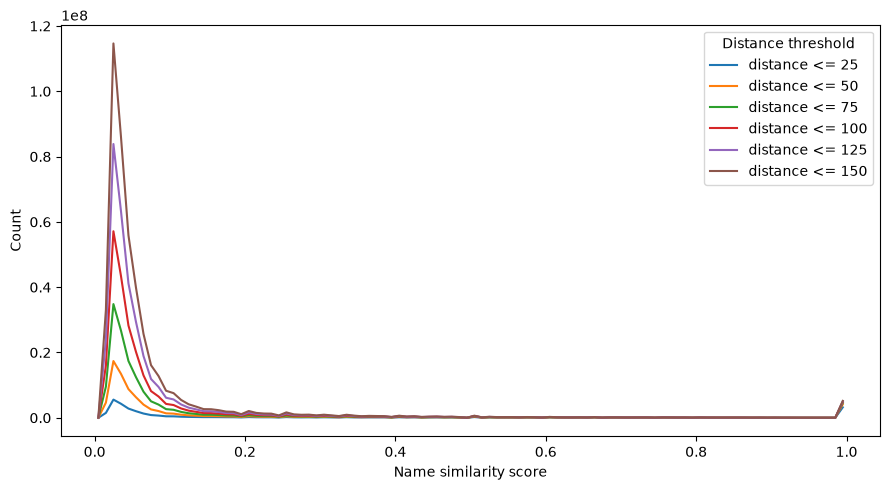

In [77]:
plot_threshold_comparison(data_by_distance)

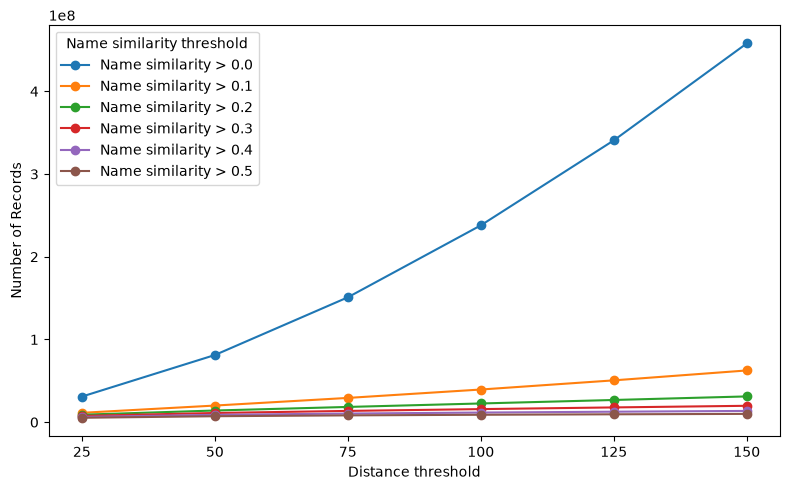

In [78]:
plot_rows([data_by_distance, data_by_distance_01, data_by_distance_02, data_by_distance_03, data_by_distance_04, data_by_distance_05])


Rows used after filters: 30,926,346


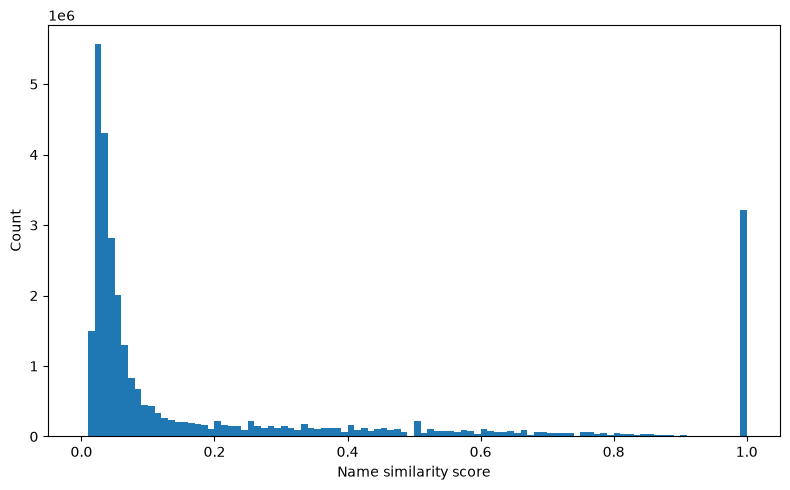

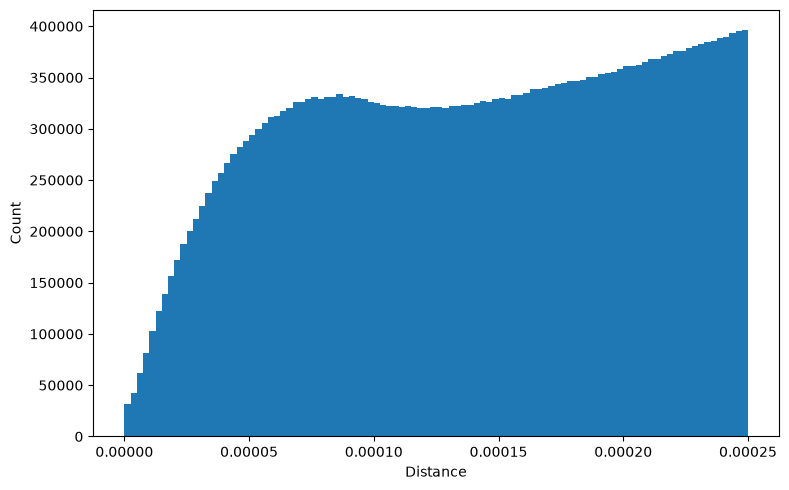

Rows used after filters: 81,172,216


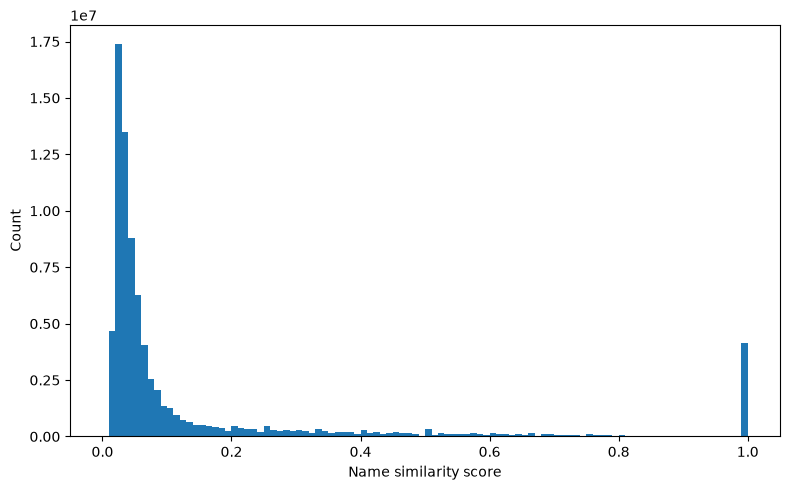

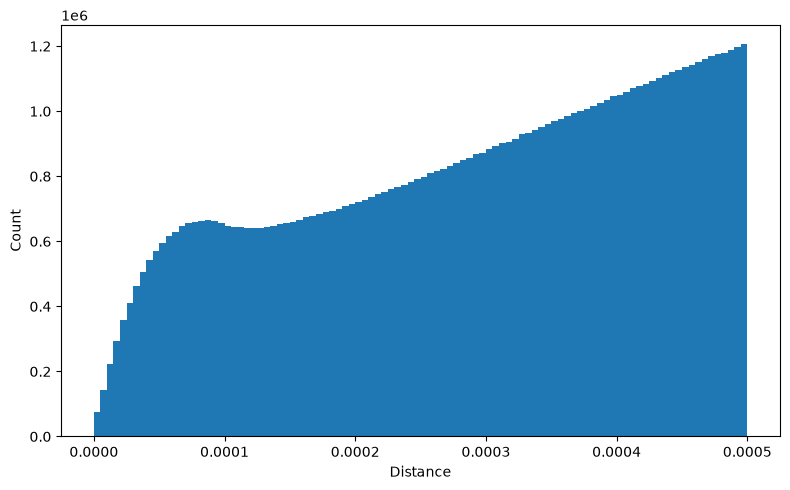

Rows used after filters: 150,941,167


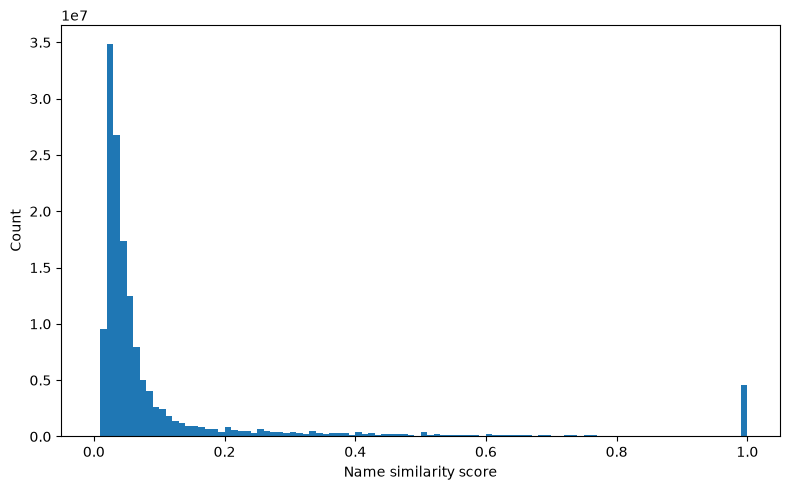

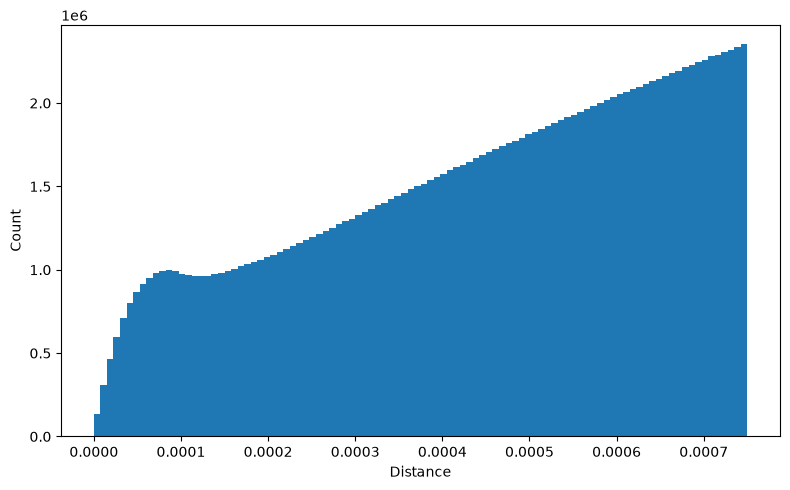

Rows used after filters: 237,925,462


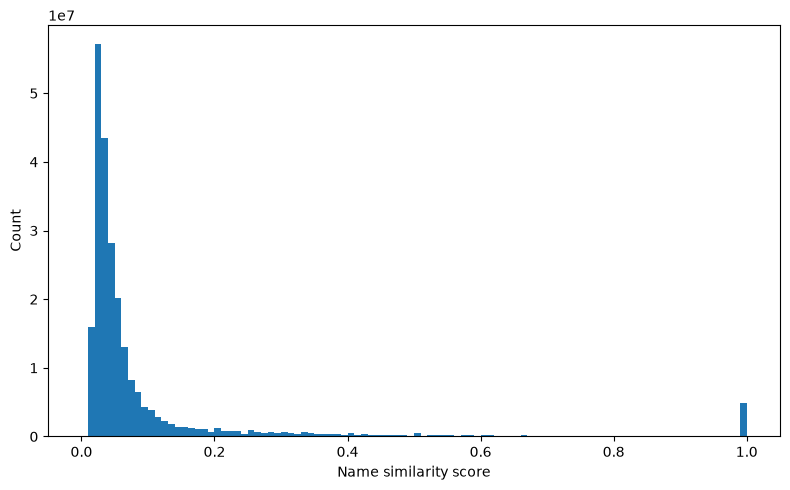

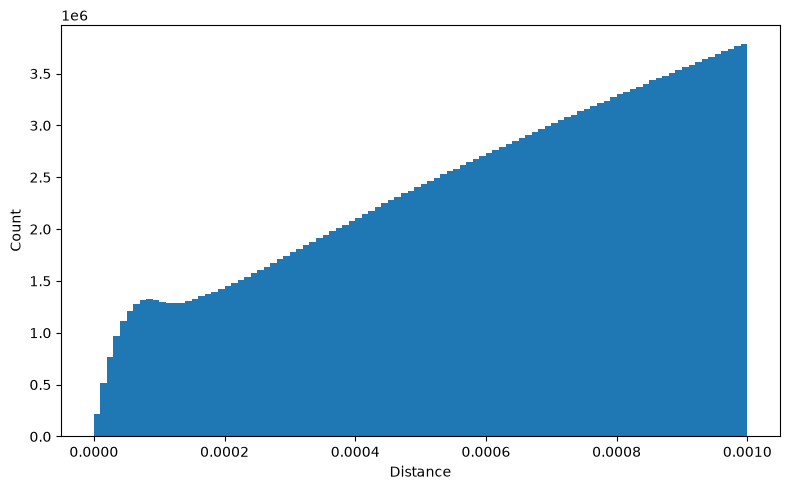

Rows used after filters: 340,663,185


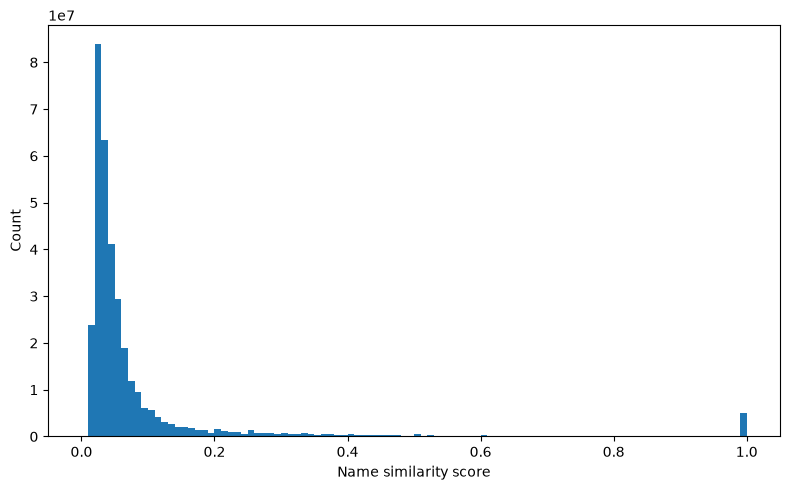

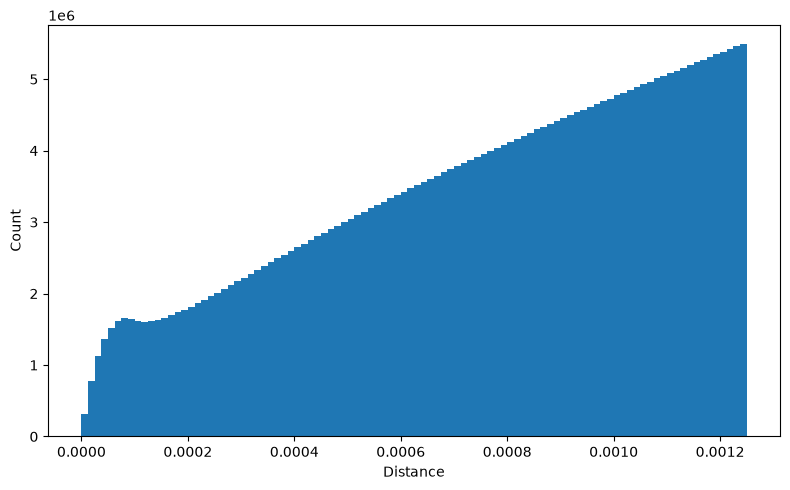

Rows used after filters: 457,861,420


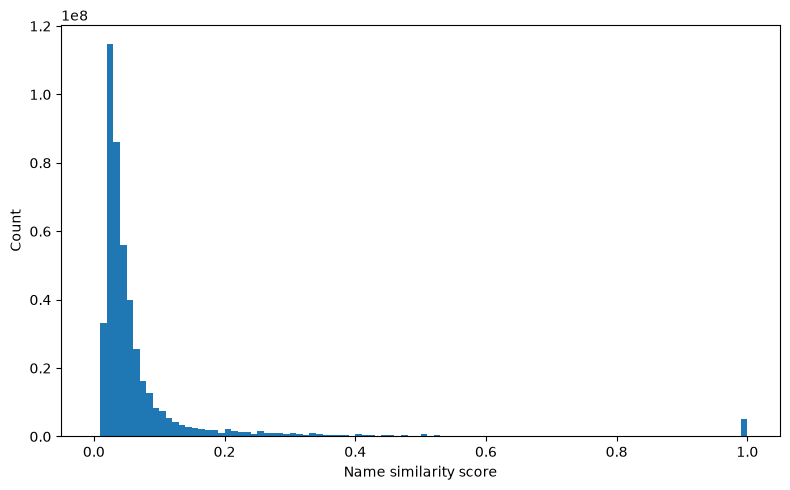

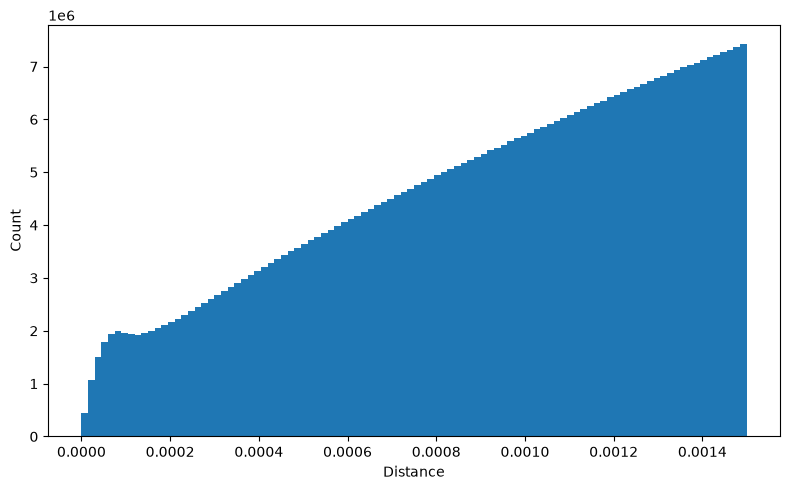

In [79]:
plot_(data_25, output_prefix="filtered_25", show=True)
plot_(data_50, output_prefix="filtered_50", show=True)
plot_(data_75, output_prefix="filtered_75", show=True)
plot_(data_100, output_prefix="filtered_100", show=True)
plot_(data_125, output_prefix="filtered_125", show=True)
plot_(data_150, output_prefix="filtered_150", show=True)

Rows used after filters: 5,313,925


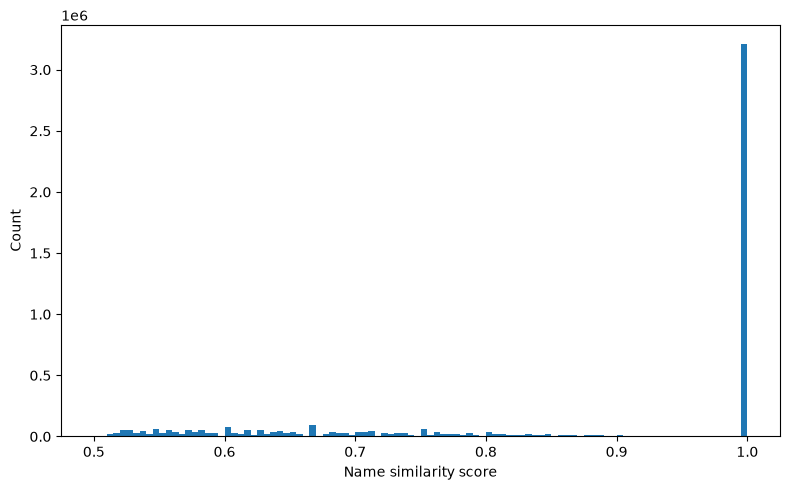

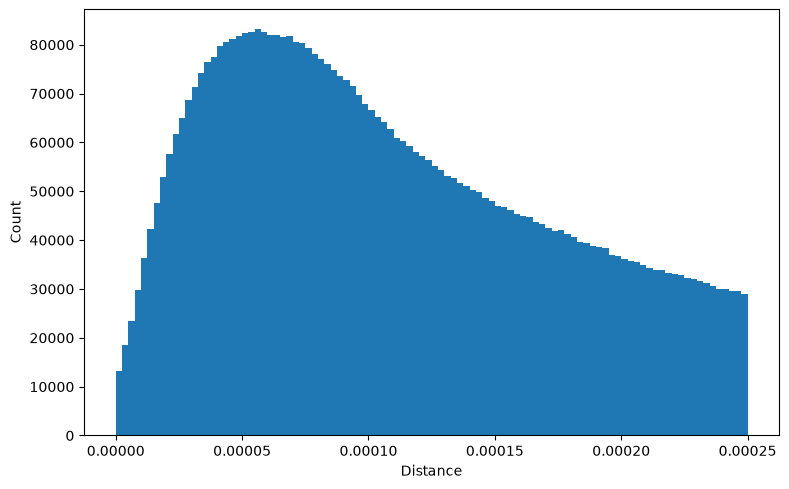

Rows used after filters: 7,205,821


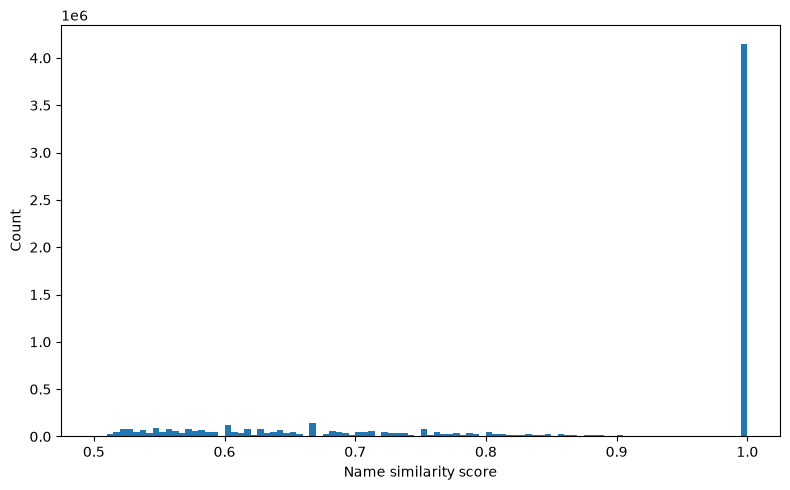

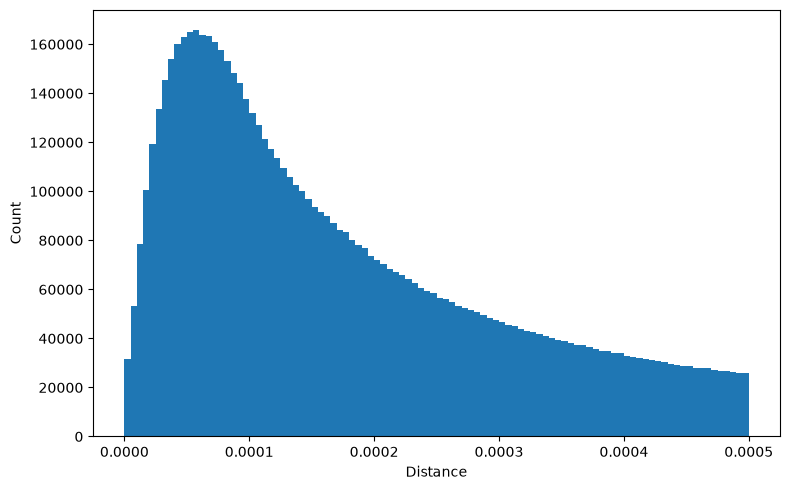

Rows used after filters: 8,226,398


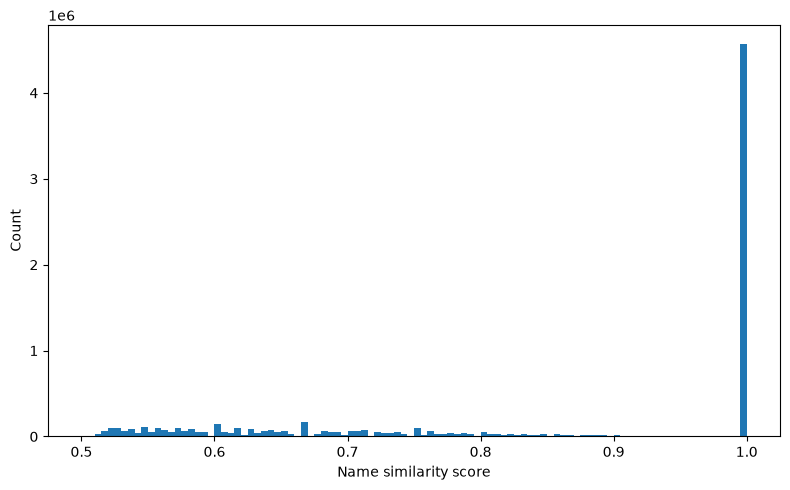

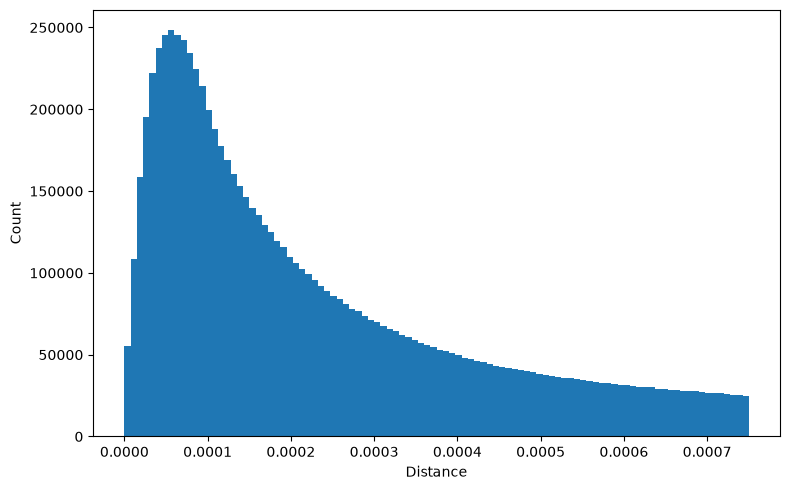

Rows used after filters: 8,950,157


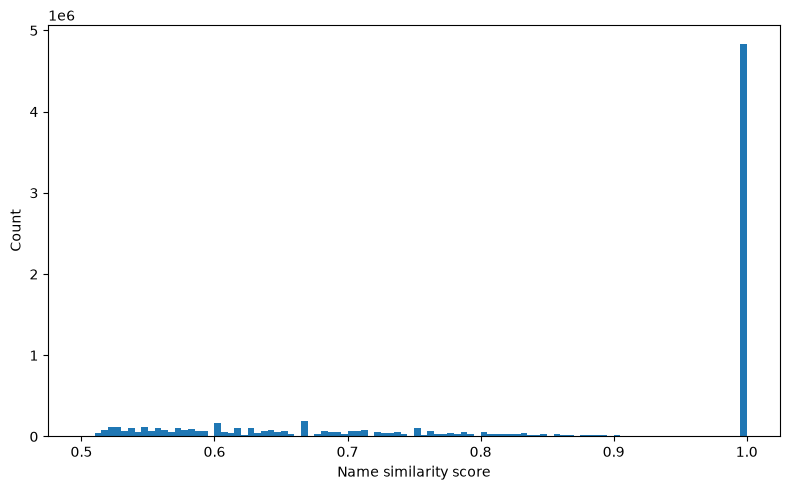

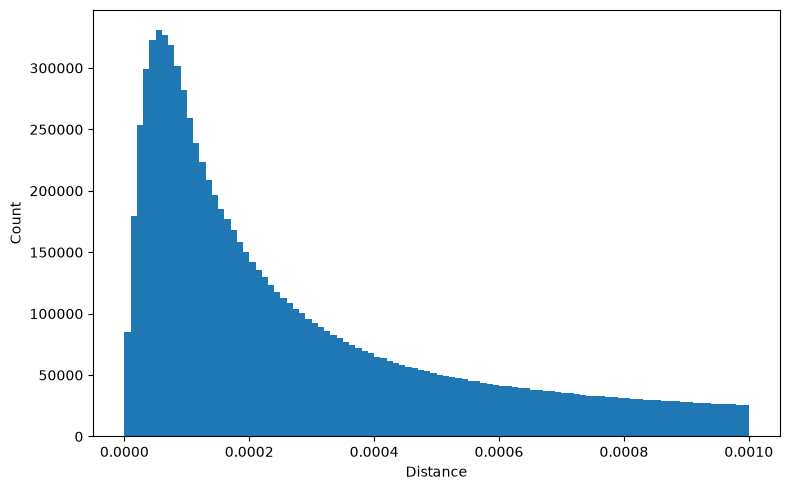

Rows used after filters: 9,526,664


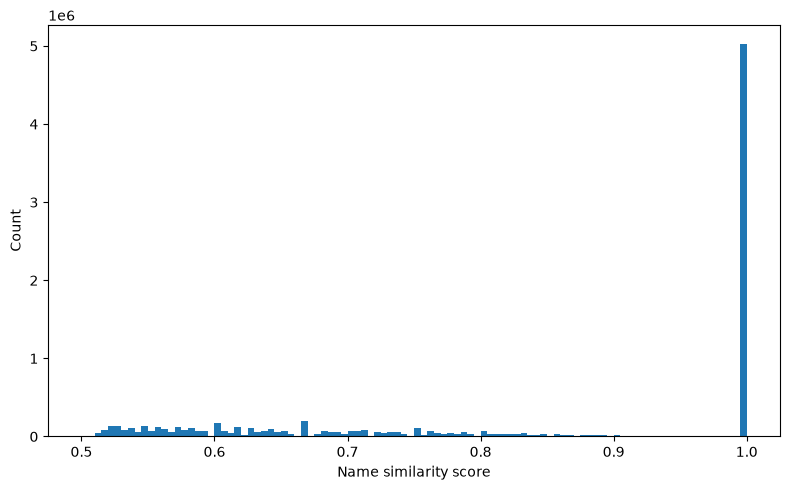

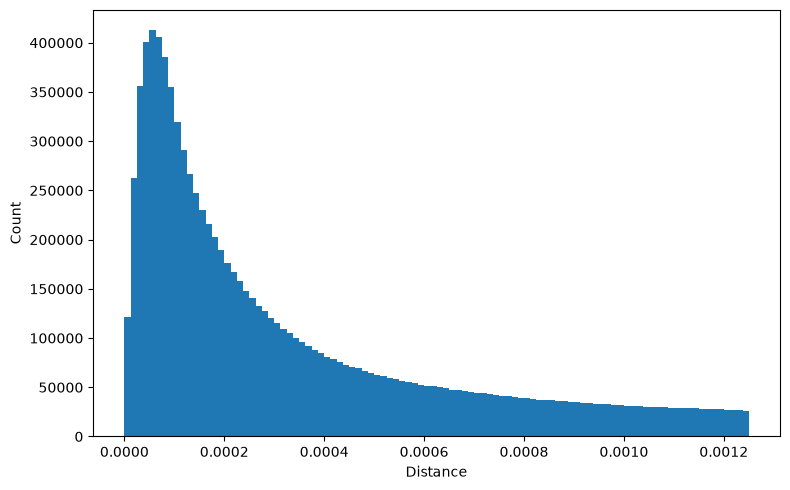

Rows used after filters: 10,018,555


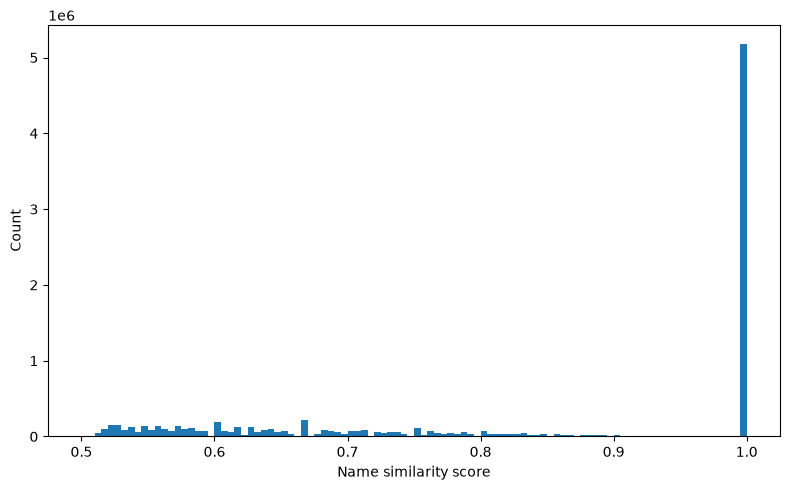

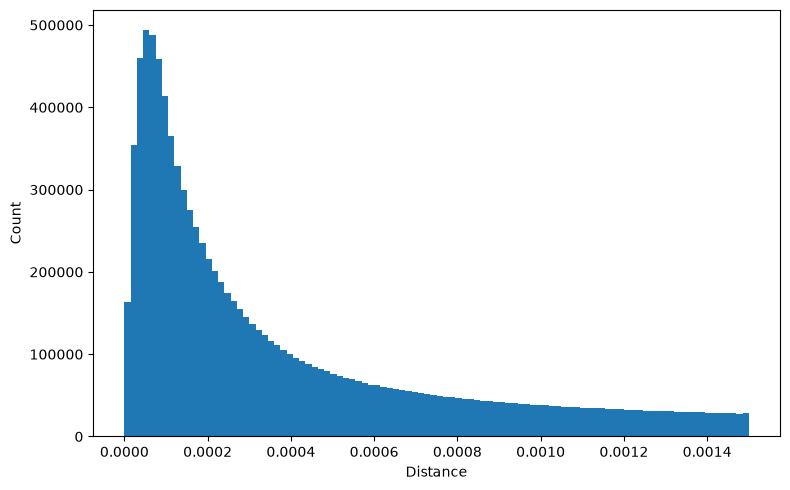

In [80]:
plot_(data_25_05, output_prefix="filtered_25_05", show=True)
plot_(data_50_05, output_prefix="filtered_50_05", show=True)
plot_(data_75_05, output_prefix="filtered_75_05", show=True)
plot_(data_100_05, output_prefix="filtered_100_05", show=True)
plot_(data_125_05, output_prefix="filtered_125_05", show=True)
plot_(data_150_05, output_prefix="filtered_150_05", show=True)